# Uber Ride Bookings 2024 — Cleaning, Analysis & Dashboard

**Dataset:** `ncr_ride_bookings.csv` — 150,000 ride booking records from Uber operations in the NCR (Delhi-NCR) region, 2024.

This notebook does four things, in order:

1. **Load & Explore** — understand what's actually in the raw file
2. **Clean** — fix real formatting problems, and handle missing data based on *why* it's missing (not guesswork)
3. **Analyze & Visualize** — find patterns in bookings, revenue, cancellations, and ratings
4. **Dashboard** — generate a Streamlit app (`app.py`) so the analysis can be explored interactively

> **A note on missing values:** A lot of the "missing" data in this dataset isn't actually missing — it's *not applicable*. For example, a ride that was cancelled before pickup was never rated, because it never happened. Filling that in with an average rating would be inventing a fact. So instead of blindly filling every blank cell, this notebook first figures out **why** each value is blank, and only fills it when there's a real, defensible reason to.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# A small, consistent color palette used across every chart in this notebook
PALETTE = ['#2E86AB', '#F26419', '#33A02C', '#8E44AD', '#F1C40F', '#E63946', '#118AB2']
STATUS_COLORS = {
    'Completed': '#2E86AB',
    'Cancelled by Driver': '#E63946',
    'Cancelled by Customer': '#F26419',
    'No Driver Found': '#8E44AD',
    'Incomplete': '#F1C40F',
}

RAW_FILE = 'ncr_ride_bookings.csv'
CLEANED_FILE = 'cleaned_uber_data.csv'

## 2. Load the Raw Data

We explicitly tell pandas that the literal text `"null"` in the CSV means "missing" — the file uses that word instead of leaving cells blank, so we need to say so up front rather than relying on defaults.

In [2]:
df = pd.read_csv(RAW_FILE, na_values=['null', 'NULL', 'Null', ''])

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 150,000
Columns: 21


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## 3. First Look at the Data

Before touching anything, let's understand what we're working with: data types, missing values, and duplicate rows.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [4]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_%': (df.isnull().mean() * 100).round(1)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing

,missing_count,missing_%
Incomplete Rides,141000,94.0
Incomplete Rides Reason,141000,94.0
Cancelled Rides by Customer,139500,93.0
Reason for cancelling by Customer,139500,93.0
Cancelled Rides by Driver,123000,82.0
Driver Cancellation Reason,123000,82.0
Driver Ratings,57000,38.0
Customer Rating,57000,38.0
Avg CTAT,48000,32.0
Booking Value,48000,32.0


**Observation:** Ten columns have missing values, and several are missing over 80% of the time. Before deciding what to do about that, let's see whether the missingness follows a pattern.

In [5]:
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate Booking IDs:", df['Booking ID'].duplicated().sum(), "out of", len(df))
print()
print("Booking Status breakdown:")
print(df['Booking Status'].value_counts())
print()
print("Vehicle Type breakdown:")
print(df['Vehicle Type'].value_counts())

Full duplicate rows: 0
Duplicate Booking IDs: 1233 out of 150000

Booking Status breakdown:
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

Vehicle Type breakdown:
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64


In [6]:
# Does missingness line up with Booking Status? This tells us whether it's random or structural.
value_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance',
              'Driver Ratings', 'Customer Rating', 'Payment Method']
df.groupby('Booking Status')[value_cols].apply(lambda x: x.notnull().sum())

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
Booking Status,,,,,,,
Cancelled by Customer,10500,0,0,0,0,0,0
Cancelled by Driver,27000,0,0,0,0,0,0
Completed,93000,93000,93000,93000,93000,93000,93000
Incomplete,9000,9000,9000,9000,0,0,9000
No Driver Found,0,0,0,0,0,0,0


**This is the key finding of the cleaning stage.** The missing values are not random — they line up exactly with what actually happened on each ride:

| Booking Status | What's filled in | What's blank, and why |
|---|---|---|
| **Completed** | Everything | Nothing — the ride ran start to finish |
| **Incomplete** | VTAT, CTAT, fare, distance, payment | No ratings — the trip didn't finish properly, so no one rated it |
| **Cancelled by Customer** | VTAT only | Everything trip-related — cancelled before the trip happened |
| **Cancelled by Driver** | VTAT only | Same as above |
| **No Driver Found** | Nothing | No driver was ever assigned, so there's no trip data of any kind |

So a blank "Booking Value" on a cancelled ride isn't missing data to recover — it's the correct value, because **no fare was ever charged**. Filling it with an average fare would fabricate a transaction that never happened. We'll treat these as legitimately blank, not as data-entry gaps to patch.

## 4. Cleaning the Data

We'll work through this step by step, and we'll print a quick check after each step so every change is verifiable.

### 4.1 Fix the ID columns

`Booking ID` and `Customer ID` were saved with an extra pair of literal quote characters wrapped around every single value (e.g. the text `"CNR5884300"` instead of `CNR5884300`). This is a plain export formatting bug, not a data problem — every row follows the exact same pattern, so it's safe to strip.

In [7]:
print("Before:", df['Booking ID'].iloc[0], "|", df['Customer ID'].iloc[0])

df['Booking ID'] = df['Booking ID'].str.strip('"')
df['Customer ID'] = df['Customer ID'].str.strip('"')

print("After: ", df['Booking ID'].iloc[0], "|", df['Customer ID'].iloc[0])

# Confirm the fix applied cleanly to every row
assert not df['Booking ID'].str.contains('"').any()
assert not df['Customer ID'].str.contains('"').any()
print("\\nAll IDs cleaned successfully.")

Before: "CNR5884300" | "CID1982111"
After:  CNR5884300 | CID1982111
\nAll IDs cleaned successfully.


### 4.2 Clean up text columns

Trim stray whitespace from every text column, just in case (defensive — a quick check shows this dataset doesn't actually have any, but it costs nothing to be sure).

In [8]:
text_cols = df.select_dtypes(include='object').columns.tolist()
# (Booking ID / Customer ID already handled above; re-running strip on them is harmless)
for c in text_cols:
    df[c] = df[c].str.strip()

print("Text columns cleaned:", text_cols)

Text columns cleaned: ['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason', 'Payment Method']


### 4.3 Parse Date & Time, and build time-based features

`Date` and `Time` are stored as separate text columns. We combine them into a proper datetime column and pull out the pieces (hour, day of week, month) that we'll need for the time-pattern analysis later.

In [9]:
df['Booking DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%Y-%m-%d %H:%M:%S')
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

df['Hour'] = df['Booking DateTime'].dt.hour
df['Day of Week'] = df['Booking DateTime'].dt.day_name()
df['Month'] = df['Booking DateTime'].dt.month_name()
df['Month Num'] = df['Booking DateTime'].dt.month
df['Is Weekend'] = df['Booking DateTime'].dt.dayofweek >= 5

print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
df[['Date', 'Time', 'Booking DateTime', 'Hour', 'Day of Week', 'Month', 'Is Weekend']].head()

Date range: 2024-01-01 to 2024-12-30


,Date,Time,Booking DateTime,Hour,Day of Week,Month,Is Weekend
0,2024-03-23,12:29:38,2024-03-23 12:29:38,12,Saturday,March,True
1,2024-11-29,18:01:39,2024-11-29 18:01:39,18,Friday,November,False
2,2024-08-23,08:56:10,2024-08-23 08:56:10,8,Friday,August,False
3,2024-10-21,17:17:25,2024-10-21 17:17:25,17,Monday,October,False
4,2024-09-16,22:08:00,2024-09-16 22:08:00,22,Monday,September,False


### 4.4 Handle the cancellation / incomplete-ride flag columns

`Cancelled Rides by Customer`, `Cancelled Rides by Driver`, and `Incomplete Rides` are flag columns that only contain `1` or blank. A blank here just means "this didn't happen for this ride" — so it's correct to fill it with `0`, not a guess.

In [10]:
flag_cols = ['Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides']
for c in flag_cols:
    df[c] = df[c].fillna(0).astype(int)

df[flag_cols].sum()

Cancelled Rides by Customer    10500
Cancelled Rides by Driver      27000
Incomplete Rides                9000
dtype: int64

### 4.5 Handle the "reason" text columns

Same logic: if a ride was never cancelled, it can't have a cancellation reason. We fill these blanks with the explicit label `"Not Applicable"` rather than leaving them blank — this is a factual statement (the field doesn't apply to that row), not an invented value.

In [11]:
reason_cols = ['Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason']
for c in reason_cols:
    df[c] = df[c].fillna('Not Applicable')

df[reason_cols].apply(lambda s: s.value_counts()).T

,AC is not working,Change of plans,Customer Demand,Customer related issue,Driver asked to cancel,Driver is not moving towards pickup location,More than permitted people in there,Not Applicable,Other Issue,Personal & Car related issues,The customer was coughing/sick,Vehicle Breakdown,Wrong Address
Reason for cancelling by Customer,1155.0,2353.0,NaN,NaN,2295.0,2335.0,NaN,139500.0,NaN,NaN,NaN,NaN,2362.0
Driver Cancellation Reason,NaN,NaN,NaN,6837.0,NaN,NaN,6686.0,123000.0,NaN,6726.0,6751.0,NaN,NaN
Incomplete Rides Reason,NaN,NaN,3040.0,NaN,NaN,NaN,NaN,141000.0,2948.0,NaN,NaN,3012.0,NaN


### 4.6 What we're *not* doing, and why

The remaining blanks are in `Avg VTAT`, `Avg CTAT`, `Booking Value`, `Ride Distance`, `Driver Ratings`, `Customer Rating`, and `Payment Method`. As shown in Section 3, these are blank exactly when the corresponding event never took place (no trip, no fare, no rating).

**We leave these as missing (`NaN`)** instead of filling them with a mean, median, or zero, because:
- A `0` would look like "a free ride" or "a zero-rated driver," which is misleading.
- A mean/median would invent a fare or a rating for a trip that never happened.
- `NaN` is mathematically correct here: pandas already excludes it from `.mean()`, `.sum()`, etc., which is exactly the behavior we want — e.g., "average fare" should only be computed over rides that actually generated a fare.

This is the "no wrong guessing" principle applied consistently: we only fill a value when we can point to the actual business reason it should be that value.

### 4.7 Duplicate Booking IDs

`Booking ID` is meant to be a unique identifier, but it isn't quite unique in this file.

In [12]:
dup_count = df['Booking ID'].duplicated().sum()
print(f"Duplicated Booking ID rows: {dup_count} out of {len(df):,} ({dup_count/len(df)*100:.2f}%)")
print(f"Unique Booking IDs: {df['Booking ID'].nunique():,}")

df[df['Booking ID'].duplicated(keep=False)].sort_values('Booking ID')[
    ['Booking ID', 'Date', 'Time', 'Customer ID', 'Booking Status']
].head(6)

Duplicated Booking ID rows: 1233 out of 150,000 (0.82%)
Unique Booking IDs: 148,767


,Booking ID,Date,Time,Customer ID,Booking Status
81334,CNR1026036,2024-10-15,18:17:23,CID6480133,Completed
9192,CNR1026036,2024-07-21,17:59:41,CID6974869,No Driver Found
9587,CNR1029172,2024-12-17,19:19:02,CID6382731,Completed
1353,CNR1029172,2024-01-19,17:00:57,CID2615731,Incomplete
82029,CNR1051228,2024-11-05,16:50:20,CID3177617,Completed
110412,CNR1051228,2024-01-31,08:42:04,CID5242056,Completed


Looking at the duplicated rows above, they have different dates, times, customers, and statuses — these are clearly **different, real bookings that happened to be assigned the same ID string**. With 150,000 bookings drawn from a 7-digit ID space, a small number of random collisions is statistically expected (this is the same "birthday paradox" effect that causes shared birthdays in a room of 30 people) — it isn't evidence that any booking is fake or repeated.

Rather than guessing which row is the "real" one and dropping the other (which would delete genuine ride records), we:
1. **Keep every row** — each represents an actual, distinct booking.
2. **Add a guaranteed-unique technical key** (`Row ID`) so every record can still be referenced unambiguously.
3. **Flag which rows share an ID**, so this is fully transparent to anyone using the cleaned file downstream.

In [13]:
df.insert(0, 'Row ID', range(1, len(df) + 1))
df['Booking ID Is Duplicated'] = df['Booking ID'].duplicated(keep=False)

print(f"Rows flagged as sharing a Booking ID: {df['Booking ID Is Duplicated'].sum()}")

Rows flagged as sharing a Booking ID: 2457


### 4.8 Sanity-check the numeric ranges

A quick check for anything impossible — negative fares, negative distances, ratings outside the 1–5 scale, and so on.

In [14]:
numeric_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
summary = df[numeric_cols].describe().T
summary['negative_values'] = (df[numeric_cols] < 0).sum()
summary

,count,mean,std,min,25%,50%,75%,max,negative_values
Avg VTAT,139500.0,8.456352,3.773564,2.0,5.30,8.30,11.30,20.0,0
Avg CTAT,102000.0,29.149636,8.902577,10.0,21.60,28.80,36.80,45.0,0
Booking Value,102000.0,508.295912,395.805774,50.0,234.00,414.00,689.00,4277.0,0
Ride Distance,102000.0,24.637012,14.002138,1.0,12.46,23.72,36.82,50.0,0
Driver Ratings,93000.0,4.230992,0.436871,3.0,4.10,4.30,4.60,5.0,0
Customer Rating,93000.0,4.404584,0.437819,3.0,4.20,4.50,4.80,5.0,0


No negative values, and ratings fall inside the expected 1–5 range. Values at the high end (e.g. longer distances, higher fares) look like genuine long-distance trips rather than data errors, so nothing here needs to be removed or corrected — we'll just keep an eye on the spread when we visualize it below.

### 4.9 Finalize data types

Convert repeated text categories to pandas `category` dtype (more memory-efficient and makes grouping/plotting faster and clearer).

In [15]:
category_cols = ['Booking Status', 'Vehicle Type', 'Payment Method', 'Day of Week', 'Month']
for c in category_cols:
    df[c] = df[c].astype('category')

print(df.dtypes)

Row ID                                        int64
Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                             category
Customer ID                                  object
Vehicle Type                               category
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                   int64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                     int64
Driver Cancellation Reason                   object
Incomplete Rides                              int64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratin

### 4.10 Save the cleaned dataset

In [16]:
df.to_csv(CLEANED_FILE, index=False)
print(f"Saved cleaned dataset -> {CLEANED_FILE}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Saved cleaned dataset -> cleaned_uber_data.csv
Final shape: 150,000 rows x 29 columns


,Row ID,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Booking DateTime,Hour,Day of Week,Month,Month Num,Is Weekend,Booking ID Is Duplicated
0,1,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,0,Not Applicable,0,Not Applicable,0,Not Applicable,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,March,3,True,False
1,2,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,Not Applicable,0,Not Applicable,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,November,11,False,False
2,3,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,0,Not Applicable,0,Not Applicable,0,Not Applicable,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,August,8,False,False
3,4,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0,Not Applicable,0,Not Applicable,0,Not Applicable,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,October,10,False,False
4,5,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,0,Not Applicable,0,Not Applicable,0,Not Applicable,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,September,9,False,False


## 5. Exploratory Analysis & Visualizations

With the data cleaned, we can now look for patterns. Each chart below is followed by a short takeaway.

### 5.1 The Big Picture

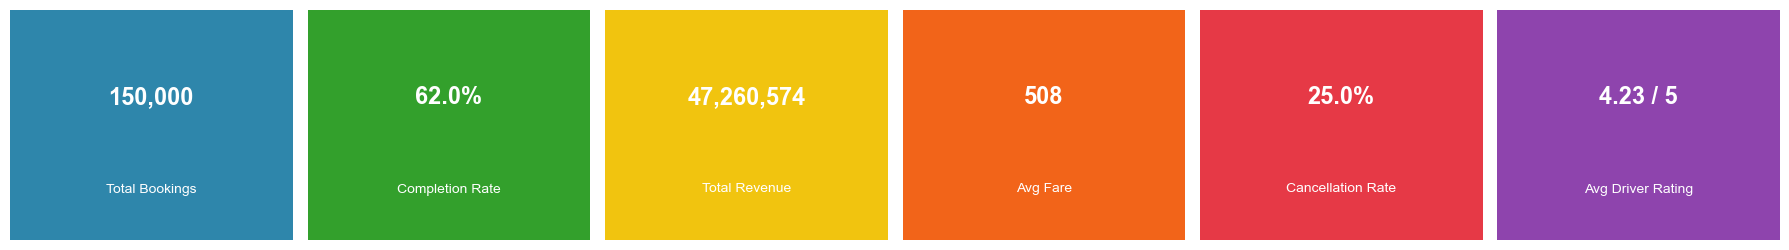

In [17]:
total_bookings = len(df)
completed = df[df['Booking Status'] == 'Completed']
completion_rate = len(completed) / total_bookings * 100
cancel_rate = (df['Cancelled Rides by Customer'].sum() + df['Cancelled Rides by Driver'].sum()) / total_bookings * 100
total_revenue = completed['Booking Value'].sum()
avg_fare = completed['Booking Value'].mean()
avg_rating = completed['Driver Ratings'].mean()

kpis = [
    ("Total Bookings", f"{total_bookings:,}", PALETTE[0]),
    ("Completion Rate", f"{completion_rate:.1f}%", PALETTE[2]),
    ("Total Revenue", f"{total_revenue:,.0f}", PALETTE[4]),
    ("Avg Fare", f"{avg_fare:,.0f}", PALETTE[1]),
    ("Cancellation Rate", f"{cancel_rate:.1f}%", PALETTE[5]),
    ("Avg Driver Rating", f"{avg_rating:.2f} / 5", PALETTE[3]),
]

fig, axes = plt.subplots(1, 6, figsize=(18, 2.6))
for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha='center', va='center', fontsize=17, fontweight='bold', color='white')
    ax.text(0.5, 0.22, label, ha='center', va='center', fontsize=10, color='white')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()

### 5.2 Booking Status

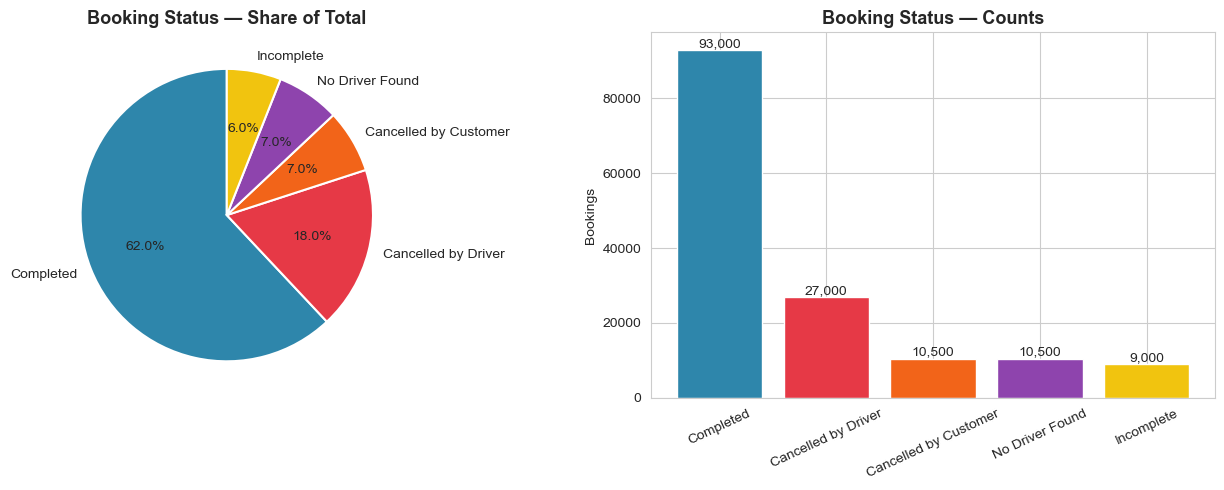

62.0% of bookings complete successfully.
25.0% are cancelled (by either side).
7.0% never even get a driver assigned.


In [18]:
status_counts = df['Booking Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = [STATUS_COLORS[s] for s in status_counts.index]

axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Booking Status — Share of Total')

bars = axes[1].bar(status_counts.index, status_counts.values, color=colors)
axes[1].set_title('Booking Status — Counts')
axes[1].bar_label(bars, fmt='{:,.0f}')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylabel('Bookings')

plt.tight_layout()
plt.show()

print(f"{status_counts['Completed']/total_bookings*100:.1f}% of bookings complete successfully.")
print(f"{(status_counts['Cancelled by Driver']+status_counts['Cancelled by Customer'])/total_bookings*100:.1f}% are cancelled (by either side).")
print(f"{status_counts['No Driver Found']/total_bookings*100:.1f}% never even get a driver assigned.")

**Takeaway:** Only 62% of bookings complete successfully. Driver-side cancellations (18%) are almost 3x more common than customer-side cancellations (7%) — this points to a driver-side/supply problem as the bigger lever for improving completion rate, more than customer behavior.

### 5.3 Vehicle Type — Volume & Revenue

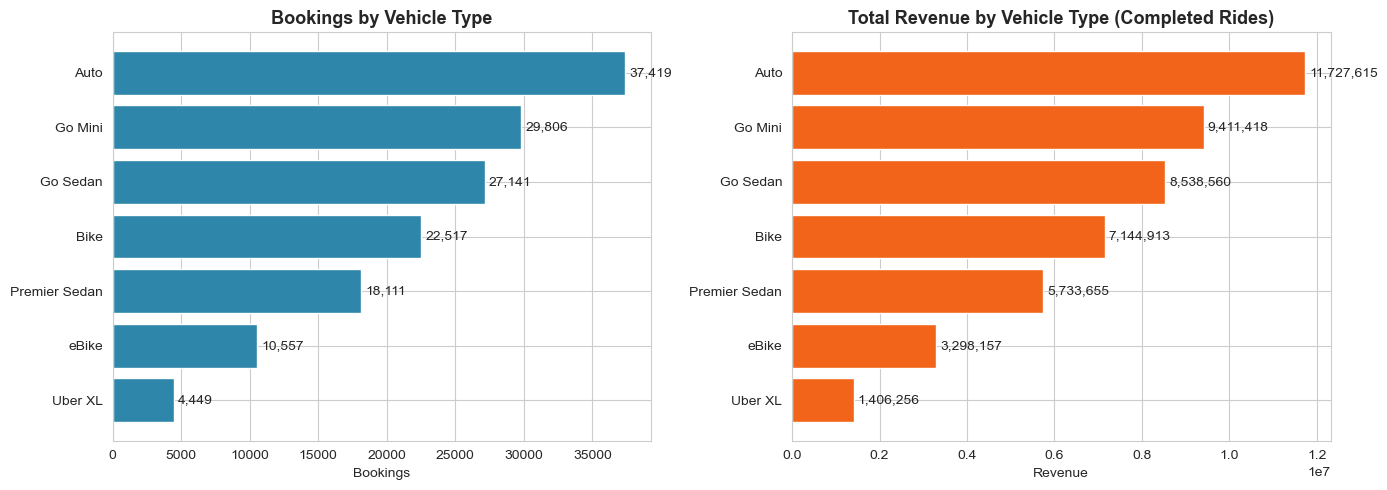

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vt_counts = df['Vehicle Type'].value_counts()
bars = axes[0].barh(vt_counts.index[::-1], vt_counts.values[::-1], color=PALETTE[0])
axes[0].set_title('Bookings by Vehicle Type')
axes[0].bar_label(bars, fmt='{:,.0f}', padding=3)
axes[0].set_xlabel('Bookings')

vt_revenue = completed.groupby('Vehicle Type', observed=True)['Booking Value'].sum().sort_values()
bars2 = axes[1].barh(vt_revenue.index, vt_revenue.values, color=PALETTE[1])
axes[1].set_title('Total Revenue by Vehicle Type (Completed Rides)')
axes[1].bar_label(bars2, fmt='{:,.0f}', padding=3)
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.show()

In [20]:
vt_summary = completed.groupby('Vehicle Type', observed=True).agg(
    bookings=('Booking Value', 'count'),
    avg_fare=('Booking Value', 'mean'),
    avg_distance=('Ride Distance', 'mean'),
    avg_rating=('Driver Ratings', 'mean')
).round(2).sort_values('bookings', ascending=False)
vt_summary

,bookings,avg_fare,avg_distance,avg_rating
Vehicle Type,,,,
Auto,23155,506.48,25.99,4.23
Go Mini,18549,507.38,25.99,4.23
Go Sedan,16676,512.03,25.98,4.23
Bike,14034,509.11,26.00,4.23
Premier Sedan,11252,509.57,25.95,4.23
eBike,6551,503.46,26.34,4.23
Uber XL,2783,505.30,25.72,4.24


**Takeaway:** Volume and revenue don't move together in the same order — a vehicle type with fewer bookings can still contribute meaningfully to revenue if its average fare is higher (longer trips or a premium price point). Check the table above against the chart to see which vehicle types are "high volume, low fare" vs. "low volume, high fare." 

### 5.4 Revenue Trend Over the Year

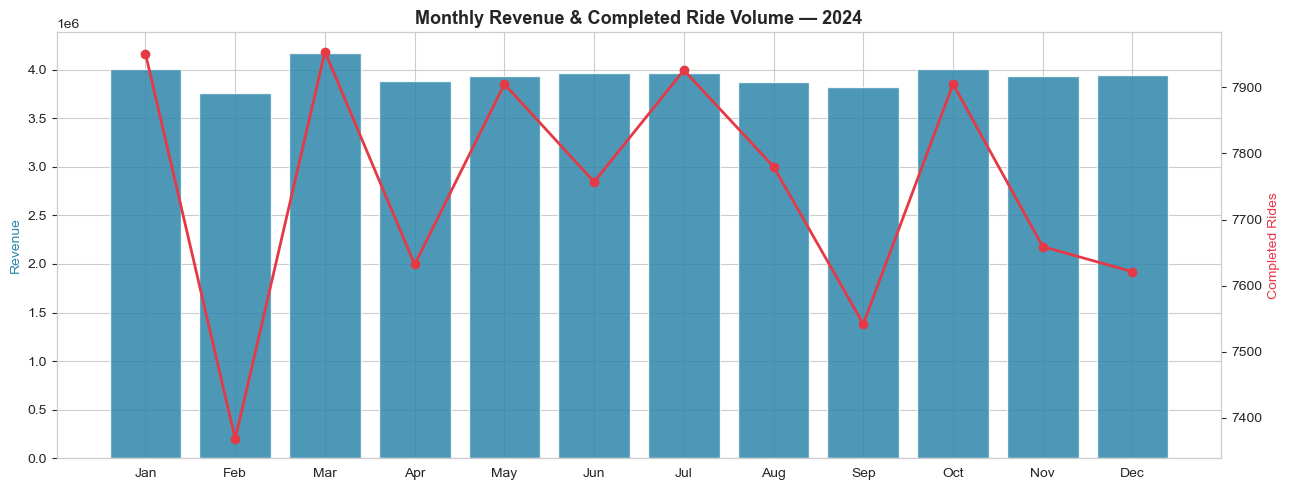

In [21]:
monthly_revenue = completed.groupby('Month Num').agg(
    revenue=('Booking Value', 'sum'),
    rides=('Booking Value', 'count')
)
month_names = pd.date_range('2024-01-01', periods=12, freq='MS').strftime('%b')
monthly_revenue.index = month_names

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(monthly_revenue.index, monthly_revenue['revenue'], color=PALETTE[0], alpha=0.85, label='Revenue')
ax1.set_ylabel('Revenue', color=PALETTE[0])
ax1.set_title('Monthly Revenue & Completed Ride Volume — 2024')

ax2 = ax1.twinx()
ax2.plot(monthly_revenue.index, monthly_revenue['rides'], color=PALETTE[5], marker='o', linewidth=2, label='Completed Rides')
ax2.set_ylabel('Completed Rides', color=PALETTE[5])
ax2.grid(False)

fig.tight_layout()
plt.show()

**Takeaway:** Revenue tracks completed-ride volume closely month to month, which makes sense (more completed rides = more fares). Any month where the two lines *diverge* — revenue rising while ride count is flat, or vice versa — is worth a closer look, since it means average fare itself shifted that month.

### 5.5 Cancellations — Who, and Why

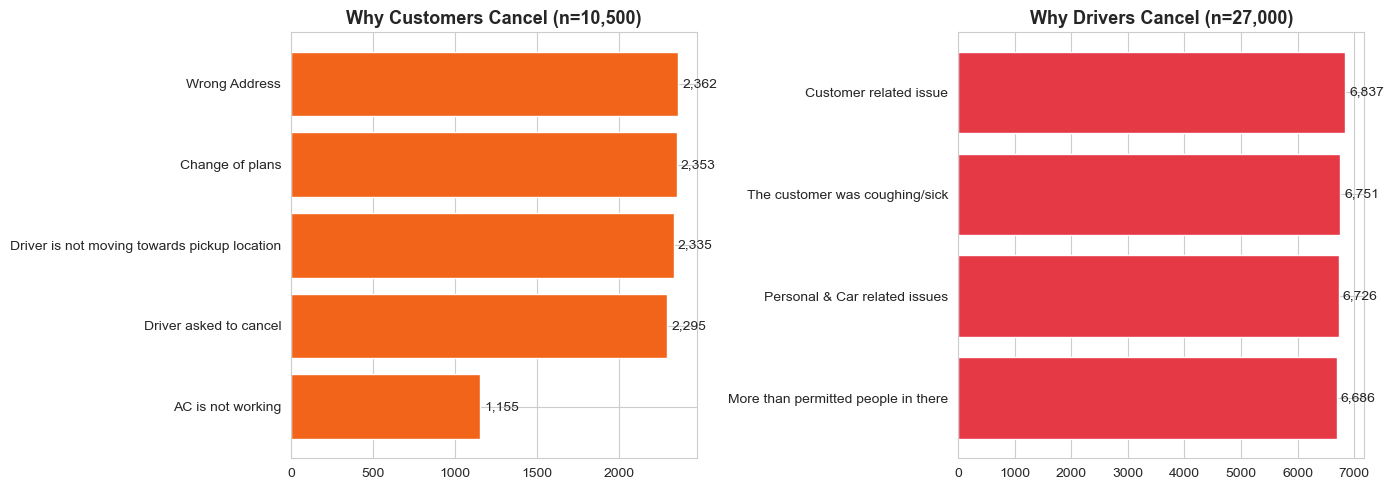

In [22]:
cust_reasons = df.loc[df['Cancelled Rides by Customer'] == 1, 'Reason for cancelling by Customer'].value_counts()
driver_reasons = df.loc[df['Cancelled Rides by Driver'] == 1, 'Driver Cancellation Reason'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(cust_reasons.index[::-1], cust_reasons.values[::-1], color=PALETTE[1])
axes[0].set_title(f'Why Customers Cancel (n={cust_reasons.sum():,})')
axes[0].bar_label(bars, fmt='{:,.0f}', padding=3)

bars2 = axes[1].barh(driver_reasons.index[::-1], driver_reasons.values[::-1], color=PALETTE[5])
axes[1].set_title(f'Why Drivers Cancel (n={driver_reasons.sum():,})')
axes[1].bar_label(bars2, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.show()

**Takeaway:** Compare the top reason on each side. Customer cancellations tend to be about the *driver's approach* (e.g. not moving toward pickup) — something Uber's driver-dispatch/ETA system could address. Driver cancellations tend to be about the *trip itself* (e.g. rider/vehicle mismatch) — a different kind of fix (screening, policy) than a dispatch fix.

### 5.6 Cancellation Rate by Vehicle Type

Does the chance of a ride actually completing depend on which vehicle type was booked?

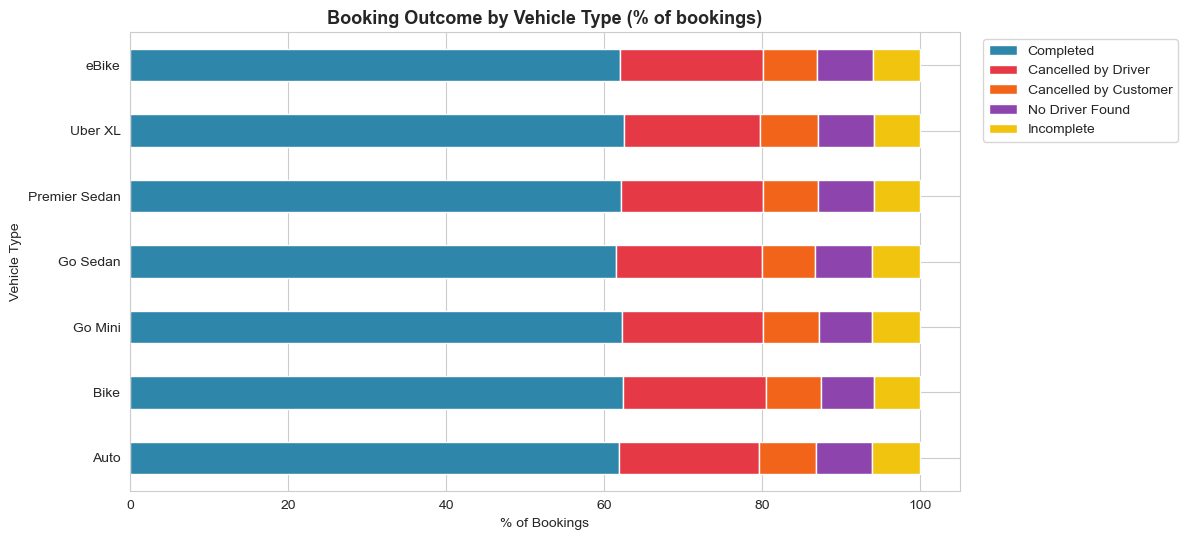

Booking Status,Completed,Cancelled by Driver,Cancelled by Customer,No Driver Found,Incomplete
Vehicle Type,,,,,
Auto,61.9,17.8,7.2,7.2,6.0
Bike,62.3,18.1,7.0,6.7,5.9
Go Mini,62.2,17.9,7.0,6.8,6.1
Go Sedan,61.4,18.5,6.7,7.2,6.0
Premier Sedan,62.1,17.9,7.0,7.1,5.9
Uber XL,62.6,17.1,7.3,7.1,5.9
eBike,62.1,18.1,6.8,7.1,6.0


In [23]:
status_by_vehicle = pd.crosstab(df['Vehicle Type'], df['Booking Status'], normalize='index') * 100
status_by_vehicle = status_by_vehicle[['Completed', 'Cancelled by Driver', 'Cancelled by Customer', 'No Driver Found', 'Incomplete']]

ax = status_by_vehicle.plot(kind='barh', stacked=True, figsize=(12, 5.5),
                             color=[STATUS_COLORS[c] for c in status_by_vehicle.columns])
ax.set_title('Booking Outcome by Vehicle Type (% of bookings)')
ax.set_xlabel('% of Bookings')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

status_by_vehicle.round(1)

**Takeaway:** If one vehicle type stands out with a noticeably lower "Completed" share (or a higher "No Driver Found" share) than the others, that's a supply/availability issue specific to that vehicle category — worth flagging to fleet operations separately from the overall cancellation-reason analysis above.

### 5.7 When Do Bookings Happen?

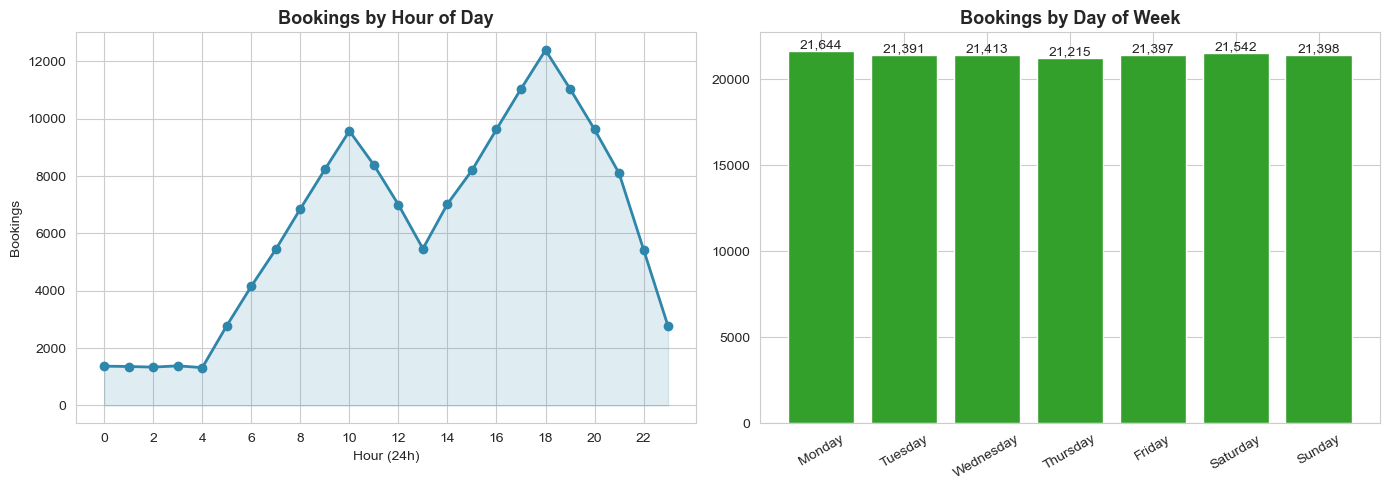

Peak hour: 18:00, with 12,397 bookings


In [24]:
hourly = df.groupby('Hour').size()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df['Day of Week'].value_counts().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly.index, hourly.values, color=PALETTE[0], marker='o', linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.15, color=PALETTE[0])
axes[0].set_title('Bookings by Hour of Day')
axes[0].set_xlabel('Hour (24h)')
axes[0].set_ylabel('Bookings')
axes[0].set_xticks(range(0, 24, 2))

bars = axes[1].bar(daily.index, daily.values, color=PALETTE[2])
axes[1].set_title('Bookings by Day of Week')
axes[1].tick_params(axis='x', rotation=30)
axes[1].bar_label(bars, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

peak_hour = hourly.idxmax()
print(f"Peak hour: {peak_hour}:00, with {hourly.max():,} bookings")

C:\Users\Kavita choudhary\AppData\Local\Temp\ipykernel_6848\54716291.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='Day of Week', columns='Hour', values='Row ID', aggfunc='count').reindex(dow_order)


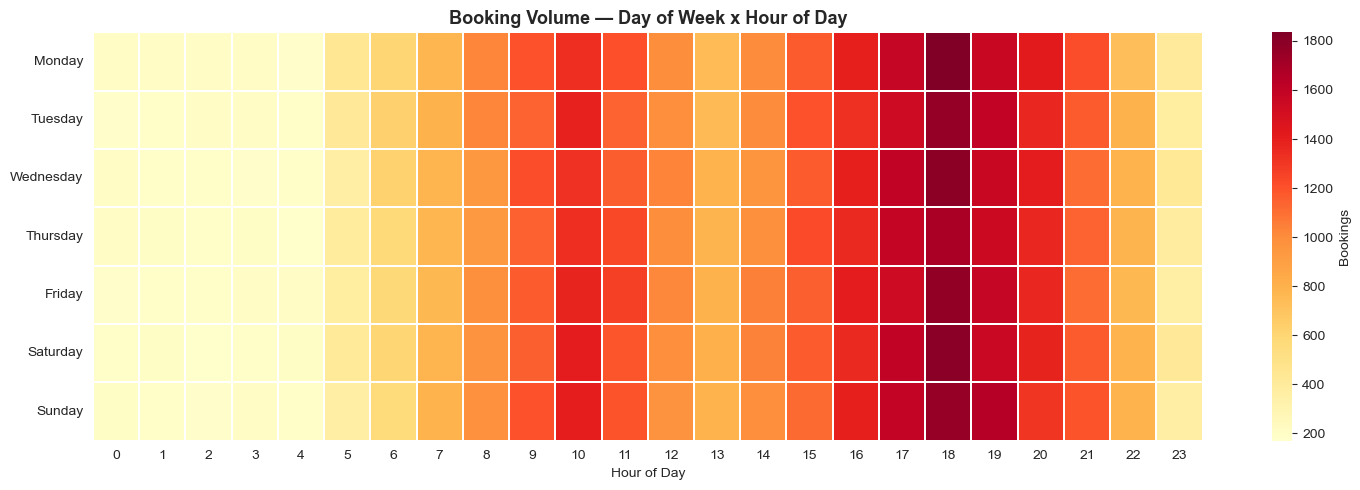

In [25]:
pivot = df.pivot_table(index='Day of Week', columns='Hour', values='Row ID', aggfunc='count').reindex(dow_order)

plt.figure(figsize=(15, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'Bookings'})
plt.title('Booking Volume — Day of Week x Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Takeaway:** The heatmap shows exactly which day/hour combinations see the most demand — that's the pattern a real operations team would use to plan driver incentives or surge pricing windows, rather than just staffing evenly across the day.

### 5.8 Ratings

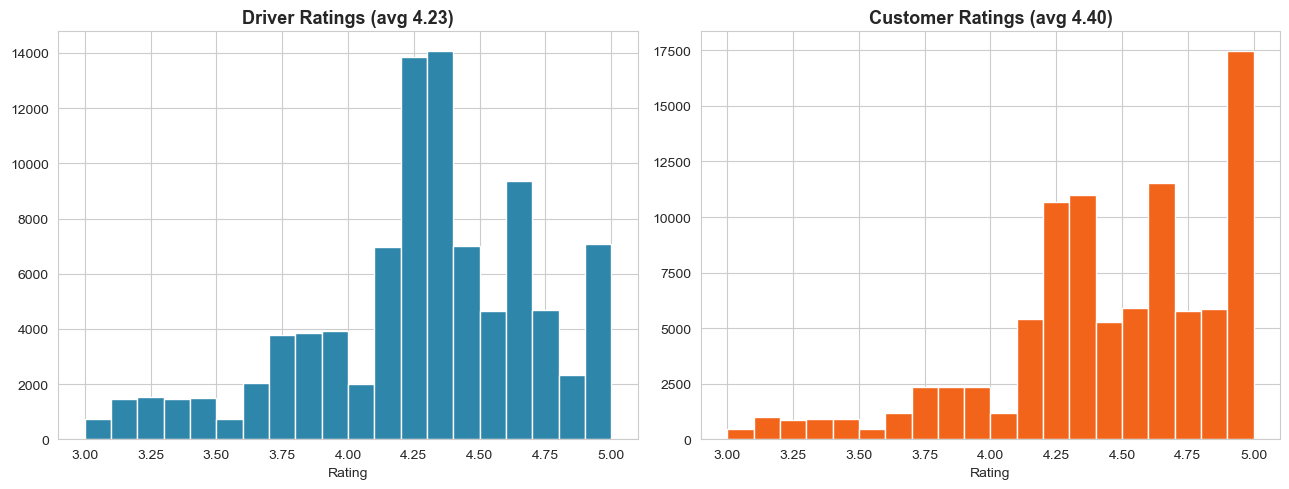

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(completed['Driver Ratings'].dropna(), bins=20, color=PALETTE[0], edgecolor='white')
axes[0].set_title(f"Driver Ratings (avg {completed['Driver Ratings'].mean():.2f})")
axes[0].set_xlabel('Rating')

axes[1].hist(completed['Customer Rating'].dropna(), bins=20, color=PALETTE[1], edgecolor='white')
axes[1].set_title(f"Customer Ratings (avg {completed['Customer Rating'].mean():.2f})")
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()

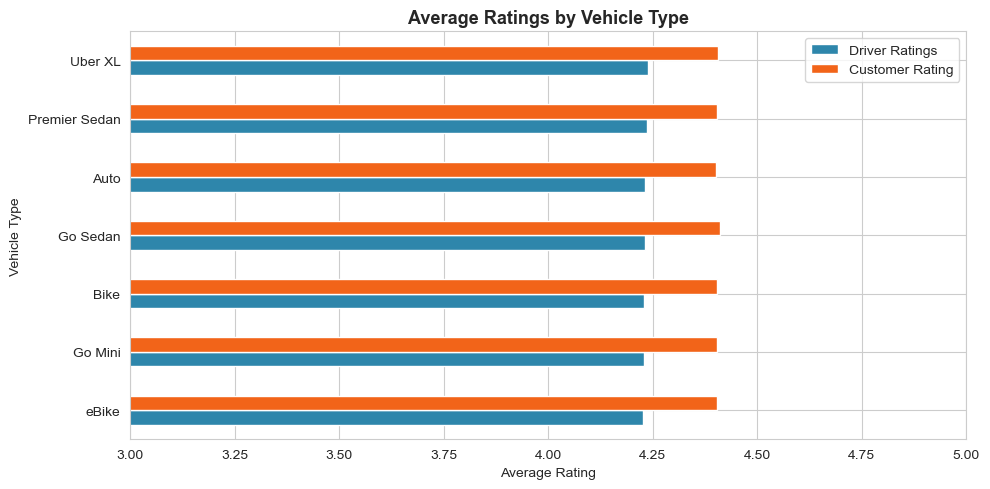

In [27]:
rating_by_vehicle = completed.groupby('Vehicle Type', observed=True)[['Driver Ratings', 'Customer Rating']].mean().sort_values('Driver Ratings')

ax = rating_by_vehicle.plot(kind='barh', figsize=(10, 5), color=[PALETTE[0], PALETTE[1]])
ax.set_title('Average Ratings by Vehicle Type')
ax.set_xlabel('Average Rating')
ax.set_xlim(3, 5)
plt.tight_layout()
plt.show()

**Takeaway:** Ratings only exist for completed rides (see Section 4.6), so this reflects service quality on rides that actually finished — not the rides that were cancelled. Both distributions skew high, which is typical of ride-hailing rating systems, so relative differences between vehicle types matter more here than the absolute scores.

### 5.9 Payment Methods

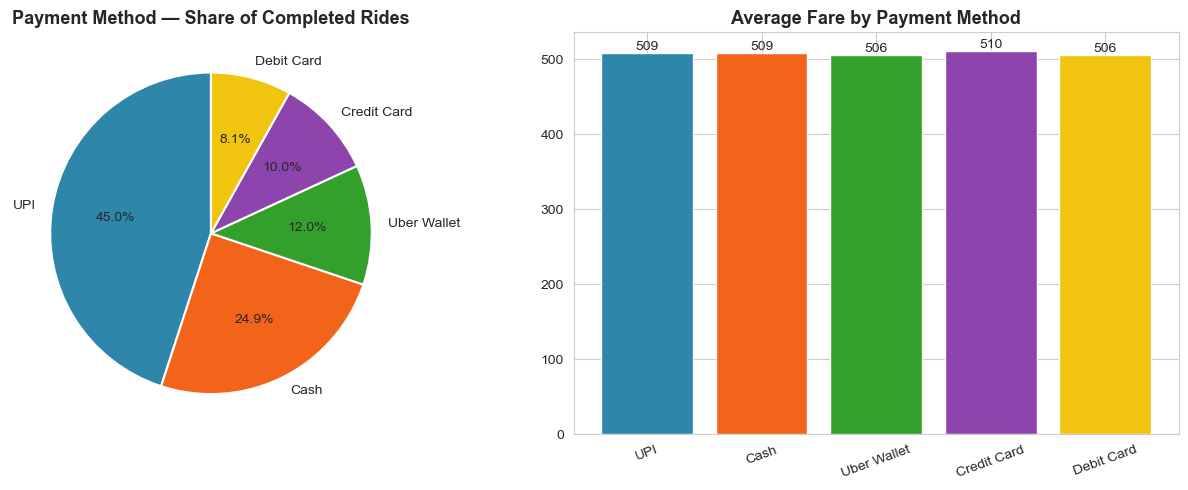

In [28]:
pm_counts = completed['Payment Method'].value_counts()
pm_value = completed.groupby('Payment Method', observed=True)['Booking Value'].mean().reindex(pm_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(pm_counts, labels=pm_counts.index, autopct='%1.1f%%', colors=PALETTE,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Payment Method — Share of Completed Rides')

bars = axes[1].bar(pm_value.index, pm_value.values, color=PALETTE)
axes[1].set_title('Average Fare by Payment Method')
axes[1].bar_label(bars, fmt='{:,.0f}')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 5.10 Where Are Rides Happening?

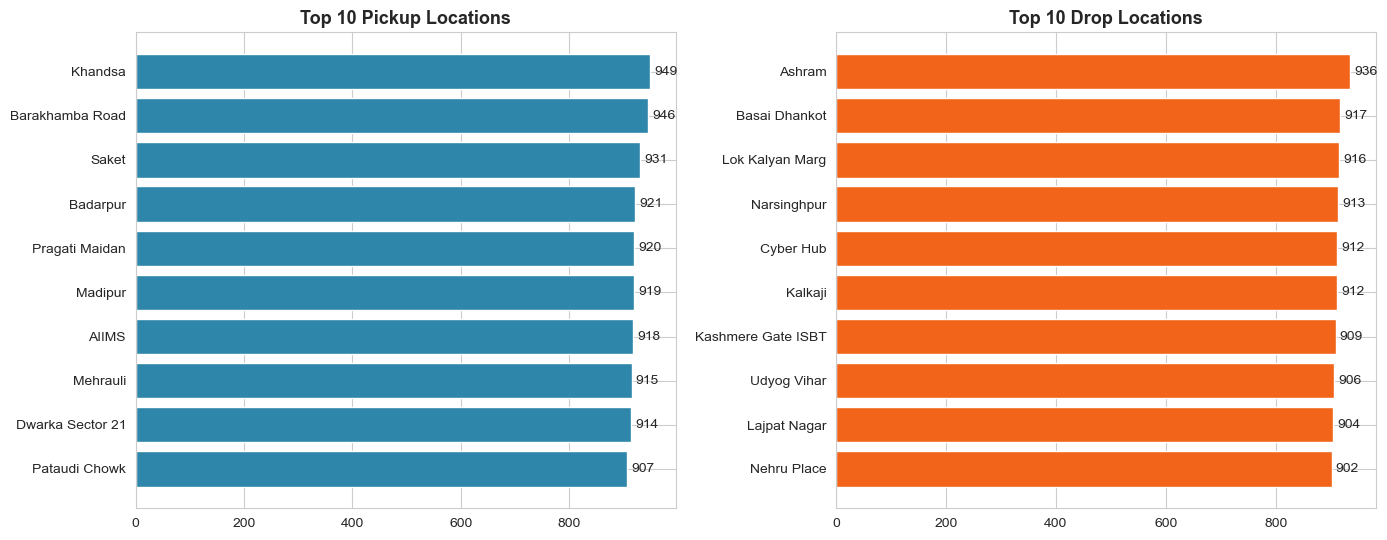

In [29]:
top_pickup = df['Pickup Location'].value_counts().head(10)
top_drop = df['Drop Location'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

bars = axes[0].barh(top_pickup.index[::-1], top_pickup.values[::-1], color=PALETTE[0])
axes[0].set_title('Top 10 Pickup Locations')
axes[0].bar_label(bars, fmt='{:,.0f}', padding=3)

bars2 = axes[1].barh(top_drop.index[::-1], top_drop.values[::-1], color=PALETTE[1])
axes[1].set_title('Top 10 Drop Locations')
axes[1].bar_label(bars2, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.show()

### 5.11 Wait Time & Trip Time (VTAT / CTAT)

`Avg VTAT` = how long the driver takes to reach pickup. `Avg CTAT` = how long the trip itself takes. Both matter for customer experience.

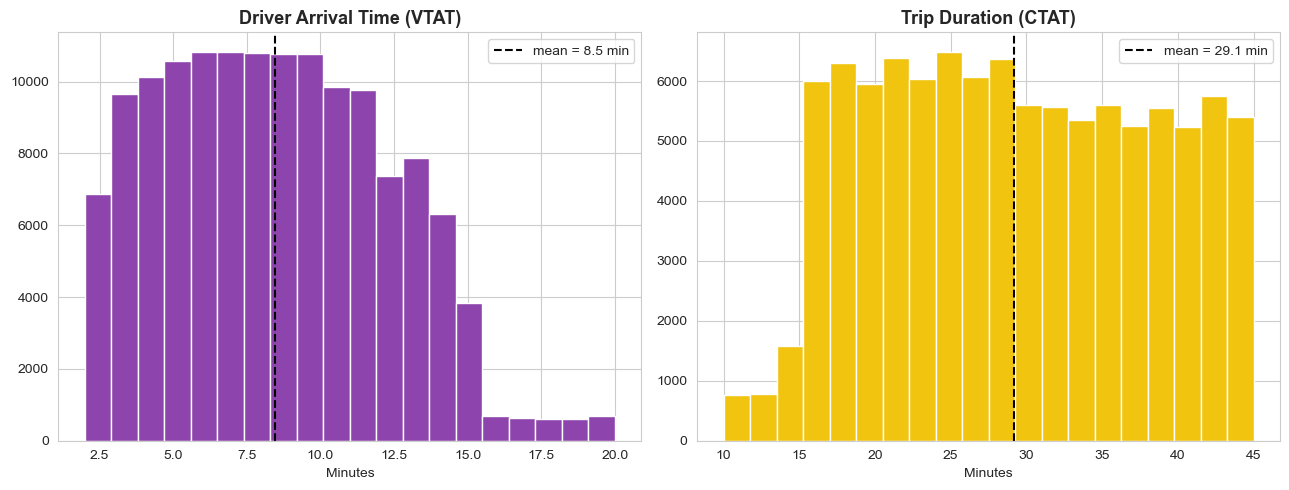

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['Avg VTAT'].dropna(), bins=20, color=PALETTE[3], edgecolor='white')
axes[0].axvline(df['Avg VTAT'].mean(), color='black', linestyle='--', label=f"mean = {df['Avg VTAT'].mean():.1f} min")
axes[0].set_title('Driver Arrival Time (VTAT)')
axes[0].set_xlabel('Minutes')
axes[0].legend()

axes[1].hist(df['Avg CTAT'].dropna(), bins=20, color=PALETTE[4], edgecolor='white')
axes[1].axvline(df['Avg CTAT'].mean(), color='black', linestyle='--', label=f"mean = {df['Avg CTAT'].mean():.1f} min")
axes[1].set_title('Trip Duration (CTAT)')
axes[1].set_xlabel('Minutes')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.12 How Fare, Distance, and Trip Time Relate

A correlation heatmap over completed rides — this shows which numeric factors move together.

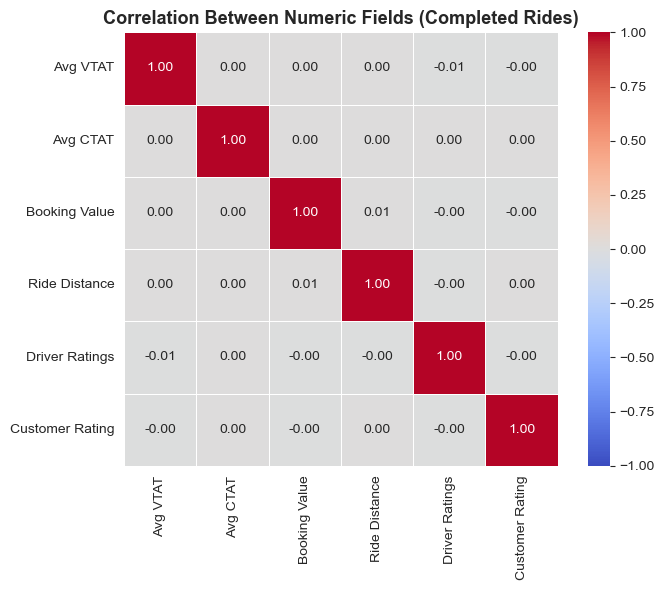

                 Avg VTAT  Avg CTAT  Booking Value  Ride Distance  Driver Ratings  Customer Rating
Avg VTAT            1.000     0.002          0.003          0.004          -0.005           -0.004
Avg CTAT            0.002     1.000          0.001          0.001           0.001            0.001
Booking Value       0.003     0.001          1.000          0.006          -0.000           -0.000
Ride Distance       0.004     0.001          0.006          1.000          -0.002            0.005
Driver Ratings     -0.005     0.001         -0.000         -0.002           1.000           -0.001
Customer Rating    -0.004     0.001         -0.000          0.005          -0.001            1.000


In [31]:
corr_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
corr = completed[corr_cols].corr()

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Correlation Between Numeric Fields (Completed Rides)')
plt.tight_layout()
plt.show()

print(corr.round(3))

**This is a real, notable finding — not the one we'd expect.** Every value in the table above is close to `0.00`. In a real ride-hailing system, fare and trip duration are normally *strongly* tied to distance — a 20 km ride should reliably cost more than a 2 km ride. Here, it doesn't. Let's confirm with a direct scatter plot before drawing conclusions.

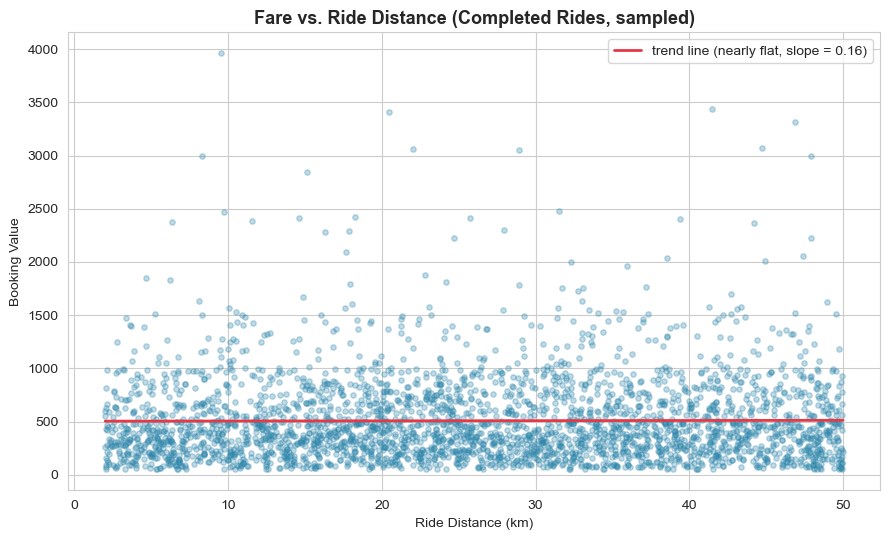

Correlation between distance and fare: 0.006


In [32]:
# Fare vs distance, sampled for readability (150k points would just look like a solid blob)
sample = completed.sample(min(3000, len(completed)), random_state=42)

plt.figure(figsize=(9, 5.5))
plt.scatter(sample['Ride Distance'], sample['Booking Value'], alpha=0.3, s=15, color=PALETTE[0])
z = np.polyfit(completed['Ride Distance'].dropna(), completed.loc[completed['Ride Distance'].notna(), 'Booking Value'], 1)
xs = np.linspace(completed['Ride Distance'].min(), completed['Ride Distance'].max(), 100)
plt.plot(xs, np.polyval(z, xs), color=PALETTE[5], linewidth=2, label=f'trend line (nearly flat, slope = {z[0]:.2f})')
plt.title('Fare vs. Ride Distance (Completed Rides, sampled)')
plt.xlabel('Ride Distance (km)')
plt.ylabel('Booking Value')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Correlation between distance and fare: {corr.loc['Ride Distance', 'Booking Value']:.3f}")

**Takeaway:** The scatter plot confirms it — the points form a flat cloud with no visible slope, and the trend line is essentially horizontal. Fare, distance, VTAT, CTAT, and ratings are all statistically independent of each other in this dataset (correlations of roughly ±0.01, i.e. no relationship at all).

This is a strong signal that **`Booking Value`, `Ride Distance`, `Avg VTAT`, and `Avg CTAT` were generated independently of each other** rather than reflecting a real pricing formula. It's worth being upfront about this rather than forcing a "fare depends on distance" story the data doesn't support: this dataset is well suited to the kind of categorical/aggregate analysis done throughout this notebook (patterns by status, vehicle type, time of day), but **it should not be used to build a fare-prediction or distance-based pricing model** — there's no real relationship there to learn.

## 6. Key Insights Summary

Pulling the numbers together into a plain-language summary. (A more detailed write-up of these, along with the full data dictionary, is in the separate `DATA_INSIGHTS.md` file delivered alongside this notebook.)

In [33]:
print("KEY INSIGHTS — computed directly from the cleaned data")
print("=" * 60)
print(f"1. Completion rate: {completion_rate:.1f}% of all bookings complete successfully.")
print(f"2. Driver-side cancellations ({status_counts['Cancelled by Driver']:,}) are "
      f"{status_counts['Cancelled by Driver']/status_counts['Cancelled by Customer']:.1f}x more common "
      f"than customer-side ({status_counts['Cancelled by Customer']:,}).")
print(f"3. {status_counts['No Driver Found']/total_bookings*100:.1f}% of bookings never get a driver assigned at all.")
print(f"4. Top customer cancellation reason: '{cust_reasons.index[0]}' ({cust_reasons.iloc[0]:,} cases).")
print(f"5. Top driver cancellation reason: '{driver_reasons.index[0]}' ({driver_reasons.iloc[0]:,} cases).")
print(f"6. Busiest booking hour: {peak_hour}:00.")
print(f"7. Total revenue from completed rides: {total_revenue:,.0f} (avg fare: {avg_fare:,.0f}).")
print(f"8. Most-used vehicle type: {vt_counts.index[0]} ({vt_counts.iloc[0]:,} bookings).")
print(f"9. Highest-revenue vehicle type: {vt_revenue.index[-1]} ({vt_revenue.iloc[-1]:,.0f} total).")
print(f"10. Distance-to-fare correlation: {corr.loc['Ride Distance', 'Booking Value']:.3f} — "
      f"essentially no relationship; fare does not scale with distance in this dataset.")

KEY INSIGHTS — computed directly from the cleaned data
1. Completion rate: 62.0% of all bookings complete successfully.
2. Driver-side cancellations (27,000) are 2.6x more common than customer-side (10,500).
3. 7.0% of bookings never get a driver assigned at all.
4. Top customer cancellation reason: 'Wrong Address' (2,362 cases).
5. Top driver cancellation reason: 'Customer related issue' (6,837 cases).
6. Busiest booking hour: 18:00.
7. Total revenue from completed rides: 47,260,574 (avg fare: 508).
8. Most-used vehicle type: Auto (37,419 bookings).
9. Highest-revenue vehicle type: Auto (11,727,615 total).
10. Distance-to-fare correlation: 0.006 — essentially no relationship; fare does not scale with distance in this dataset.


## 7. Streamlit Dashboard

Everything below is a **single code cell** that writes out `app.py` using Jupyter's `%%writefile` magic — the dashboard's full source lives right here in the notebook, and running this cell is what turns it into a runnable file.

**Streamlit apps can't run inside a notebook cell** — they need their own script launched by the `streamlit` command — so this is the one unavoidable exception to "everything in one file": the code itself is 100% here, but running it means letting this cell generate the `.py` file Streamlit needs.

**To launch the dashboard**, after running this cell, open a terminal in the same folder and run:
```bash
pip install -r requirements.txt
streamlit run app.py
```
Make sure `ncr_ride_bookings.csv` (the raw file) is in that same folder — the dashboard loads and cleans it itself, so it works standalone even if this notebook hasn't been run first.

In [34]:
%%writefile app.py
"""
Uber Ride Bookings 2024 — Interactive Dashboard
Run with: streamlit run app.py
"""
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px

st.set_page_config(page_title="Uber Ride Bookings 2024", page_icon="🚗", layout="wide")

RAW_FILE = "ncr_ride_bookings.csv"
CLEANED_FILE = "cleaned_uber_data.csv"

STATUS_COLORS = {
    "Completed": "#2E86AB",
    "Cancelled by Driver": "#E63946",
    "Cancelled by Customer": "#F26419",
    "No Driver Found": "#8E44AD",
    "Incomplete": "#F1C40F",
}


@st.cache_data
def load_and_clean_data():
    """Loads the cleaned CSV if it exists (produced by the notebook);
    otherwise cleans the raw file from scratch using the same logic
    as the analysis notebook, so this dashboard works standalone."""
    import os
    if os.path.exists(CLEANED_FILE):
        df = pd.read_csv(CLEANED_FILE, parse_dates=["Date", "Booking DateTime"])
        df["Booking Status"] = df["Booking Status"].astype("category")
        df["Vehicle Type"] = df["Vehicle Type"].astype("category")
        return df

    df = pd.read_csv(RAW_FILE, na_values=["null", "NULL", "Null", ""])

    df["Booking ID"] = df["Booking ID"].str.strip('"')
    df["Customer ID"] = df["Customer ID"].str.strip('"')
    for c in df.select_dtypes(include="object").columns:
        df[c] = df[c].str.strip()

    df["Booking DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%Y-%m-%d %H:%M:%S")
    df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
    df["Hour"] = df["Booking DateTime"].dt.hour
    df["Day of Week"] = df["Booking DateTime"].dt.day_name()
    df["Month"] = df["Booking DateTime"].dt.month_name()
    df["Month Num"] = df["Booking DateTime"].dt.month

    for c in ["Cancelled Rides by Customer", "Cancelled Rides by Driver", "Incomplete Rides"]:
        df[c] = df[c].fillna(0).astype(int)
    for c in ["Reason for cancelling by Customer", "Driver Cancellation Reason", "Incomplete Rides Reason"]:
        df[c] = df[c].fillna("Not Applicable")

    df.insert(0, "Row ID", range(1, len(df) + 1))
    return df


df = load_and_clean_data()

# ---------------------------------------------------------------- SIDEBAR
st.sidebar.title("Filters")
date_range = st.sidebar.date_input(
    "Date range",
    value=(df["Date"].min().date(), df["Date"].max().date()),
    min_value=df["Date"].min().date(),
    max_value=df["Date"].max().date(),
)
vehicle_options = st.sidebar.multiselect(
    "Vehicle type", options=sorted(df["Vehicle Type"].unique()), default=list(sorted(df["Vehicle Type"].unique()))
)
status_options = st.sidebar.multiselect(
    "Booking status", options=sorted(df["Booking Status"].unique()), default=list(sorted(df["Booking Status"].unique()))
)

mask = (
    (df["Date"].dt.date >= date_range[0])
    & (df["Date"].dt.date <= date_range[-1])
    & (df["Vehicle Type"].isin(vehicle_options))
    & (df["Booking Status"].isin(status_options))
)
fdf = df[mask]
completed = fdf[fdf["Booking Status"] == "Completed"]

# ---------------------------------------------------------------- HEADER
st.title("🚗 Uber Ride Bookings 2024 — Dashboard")
st.caption("NCR ride-booking data — cleaning notes and full analysis are in the companion notebook.")

# ---------------------------------------------------------------- KPI ROW
k1, k2, k3, k4, k5 = st.columns(5)
total = len(fdf)
completion_rate = len(fdf[fdf["Booking Status"] == "Completed"]) / total * 100 if total else 0
cancel_rate = (fdf["Cancelled Rides by Customer"].sum() + fdf["Cancelled Rides by Driver"].sum()) / total * 100 if total else 0

k1.metric("Total Bookings", f"{total:,}")
k2.metric("Completion Rate", f"{completion_rate:.1f}%")
k3.metric("Cancellation Rate", f"{cancel_rate:.1f}%")
k4.metric("Total Revenue", f"{completed['Booking Value'].sum():,.0f}")
k5.metric("Avg Rating", f"{completed['Driver Ratings'].mean():.2f}" if len(completed) else "—")

st.divider()

# ---------------------------------------------------------------- ROW 1
c1, c2 = st.columns(2)
with c1:
    st.subheader("Booking Status")
    status_counts = fdf["Booking Status"].value_counts().reset_index()
    status_counts.columns = ["Booking Status", "Count"]
    fig = px.pie(status_counts, names="Booking Status", values="Count",
                 color="Booking Status", color_discrete_map=STATUS_COLORS, hole=0.4)
    st.plotly_chart(fig, use_container_width=True)

with c2:
    st.subheader("Bookings by Vehicle Type")
    vt_counts = fdf["Vehicle Type"].value_counts().reset_index()
    vt_counts.columns = ["Vehicle Type", "Count"]
    fig = px.bar(vt_counts, x="Count", y="Vehicle Type", orientation="h", color="Count",
                 color_continuous_scale="Blues")
    st.plotly_chart(fig, use_container_width=True)

# ---------------------------------------------------------------- ROW 2
c3, c4 = st.columns(2)
with c3:
    st.subheader("Bookings by Hour of Day")
    hourly = fdf.groupby("Hour").size().reset_index(name="Bookings")
    fig = px.area(hourly, x="Hour", y="Bookings")
    st.plotly_chart(fig, use_container_width=True)

with c4:
    st.subheader("Revenue by Vehicle Type")
    rev = completed.groupby("Vehicle Type", observed=True)["Booking Value"].sum().reset_index()
    fig = px.bar(rev.sort_values("Booking Value"), x="Booking Value", y="Vehicle Type", orientation="h",
                 color="Booking Value", color_continuous_scale="Oranges")
    st.plotly_chart(fig, use_container_width=True)

# ---------------------------------------------------------------- ROW 3
st.subheader("Cancellation Reasons")
c5, c6 = st.columns(2)
with c5:
    cr = fdf.loc[fdf["Cancelled Rides by Customer"] == 1, "Reason for cancelling by Customer"].value_counts().reset_index()
    cr.columns = ["Reason", "Count"]
    fig = px.bar(cr, x="Count", y="Reason", orientation="h", title="By Customer",
                 color_discrete_sequence=["#F26419"])
    st.plotly_chart(fig, use_container_width=True)
with c6:
    dr = fdf.loc[fdf["Cancelled Rides by Driver"] == 1, "Driver Cancellation Reason"].value_counts().reset_index()
    dr.columns = ["Reason", "Count"]
    fig = px.bar(dr, x="Count", y="Reason", orientation="h", title="By Driver",
                 color_discrete_sequence=["#E63946"])
    st.plotly_chart(fig, use_container_width=True)

# ---------------------------------------------------------------- ROW 4
st.subheader("Fare vs. Distance")
if len(completed) > 0:
    sample = completed.sample(min(3000, len(completed)), random_state=42)
    fig = px.scatter(sample, x="Ride Distance", y="Booking Value", opacity=0.4,
                      color_discrete_sequence=["#2E86AB"], trendline="ols")
    st.plotly_chart(fig, use_container_width=True)

with st.expander("View filtered data"):
    st.dataframe(fdf, use_container_width=True)


Writing app.py


## 8. Summary

- **Cleaning:** fixed a formatting bug in the ID columns, parsed dates/times, and handled every missing-value column based on *why* it was missing — filling flags and reason columns where blank genuinely meant "didn't happen," and deliberately leaving fare/distance/rating fields blank where no such event occurred, instead of guessing.
- **Analysis:** looked at completion/cancellation patterns, revenue trends, timing patterns, ratings, and the fare-distance relationship.
- **Dashboard:** `app.py` (generated by Section 7) gives an interactive, filterable version of this same analysis.

See `KavitaBijarniya_ProjectReport.docx` for the full write-up of findings and the data dictionary, and `README.md` for setup instructions.